# Task 3 — Usage v3 replacements with MixUp + SAM

Repeat the completed MixUp + SAM trial using the revised data. **Only the dataset changes.**
Each model starts from fresh random weights and still predicts all nine Usage classes.

| Setting | Value |
|---|---|
| Data | Teacher images + 687 outside images; 130 replaced |
| Teacher split | Unchanged saved folds |
| Model | SmallCNN, trained from scratch |
| Validation folds | 0 and 4 only |
| Epochs / checkpoint | 30 / final epoch |
| MixUp | alpha 0.2, every training batch |
| SAM | rho 0.05 over AdamW |
| Other controls | Batch 128, seed 2753, E8 translation and cosine schedule |
| Class weights / normalization | Recomputed from each training fold only |

The previous **v2 MixUp + SAM** runs are the comparison, using the same teacher validation
images. Old model weights are never loaded. This notebook does not train the other three folds.


## 1. Fetch code from GitHub

In **VS Code**, select a fresh **Colab GPU kernel**, then choose **Run All**.

Keep the existing teacher archive and one existing v2 archive in `MyDrive/MLA2/data/`.
Add the small **`teacher_plus_rare_usage_v3_delta.zip`** there once, because this version has
new images. Later code changes come from GitHub and need no new data ZIP.

The completed results in `MyDrive/MLA2/task3_usage_mixup_sam/` are read as the reference.
New results go to `MyDrive/MLA2/task3_usage_replaced_v3_mixup_sam/`.


In [1]:
from pathlib import Path
import os
import subprocess
import sys
import tempfile

from google.colab import drive

DRIVE_MOUNT = Path("/content/drive")
drive.mount(str(DRIVE_MOUNT), force_remount=False)
DRIVE_PROJECT = DRIVE_MOUNT / "MyDrive/MLA2"
REPOSITORY = "https://github.com/TrnLin/MLA2.git"
BRANCH = "fashion-analysis-and-cleanup"

# A new checkout supplies code. Data archives never supply Python files.
with tempfile.TemporaryDirectory(prefix="usage-v3-code-", dir="/content") as temporary:
    checkout = Path(temporary) / "project"
    subprocess.run(
        ["git", "clone", "--quiet", "--depth=1", "--branch", BRANCH, REPOSITORY, str(checkout)],
        check=True,
    )
    CODE_COMMIT = subprocess.check_output(
        ["git", "-C", str(checkout), "rev-parse", "HEAD"], text=True
    ).strip()
    REPO_DIR = Path("/content") / f"MLA2-usage-v3-{CODE_COMMIT[:12]}"
    if REPO_DIR.exists():
        existing = subprocess.check_output(
            ["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"], text=True
        ).strip()
        if existing != CODE_COMMIT:
            raise RuntimeError("Local code differs. Use a fresh runtime.")
        subprocess.run(["git", "-C", str(REPO_DIR), "diff", "--quiet", "HEAD", "--", "src"], check=True)
    else:
        checkout.rename(REPO_DIR)

if "fashion.config" in sys.modules and Path(sys.modules["fashion.config"].ROOT) != REPO_DIR:
    raise RuntimeError("Old code is loaded. Restart the kernel, then Run All.")
os.environ["FASHION_PROJECT_ROOT"] = str(REPO_DIR)
os.chdir(REPO_DIR)
if str(REPO_DIR / "src") not in sys.path:
    sys.path.insert(0, str(REPO_DIR / "src"))
print("Code commit:", CODE_COMMIT)
print("Local project:", REPO_DIR)


Mounted at /content/drive
Code commit: 1e7292174d935a333b7bbddc2d10b150180370f8
Local project: /content/MLA2-usage-v3-1e7292174d93


## 2. Reuse the existing images and add the replacements

The loader accepts `usage_mixup_sam_training.zip`, `teacher_plus_rare_usage_v2_training.zip`,
or `teacher_plus_rare_usage_v2.zip`. It reads data files only. Teacher photos still come
from `task3-data.zip`. All training images are copied to local disk.


In [2]:
import json
from fashion.train.task3_usage_v3_setup import prepare_data

setup = prepare_data(
    root=REPO_DIR,
    drive_project=DRIVE_PROJECT,
    cache=Path("/content/mla2-data-archives"),
)
DRIVE_TASK_DIR = Path(setup["output_root"])
BASELINE_DIR = Path(setup["baseline_directory"])
BASELINE_REGISTRY = Path(setup["baseline_registry_path"])
LOCAL_REGISTRY = REPO_DIR / "v3_registry/results/runs.csv"
DRIVE_TASK_DIR.mkdir(parents=True, exist_ok=True)
(DRIVE_TASK_DIR / "code_and_data_setup.json").write_text(
    json.dumps({**setup, "code_commit": CODE_COMMIT, "repository": REPOSITORY}, indent=2) + "\n"
)
print("New results:", DRIVE_TASK_DIR)


Ready: usage_mixup_sam_training.zip (714 data files)
Ready: teacher_plus_rare_usage_v3_delta.zip (156 data files)
Ready: task3-data.zip (38613 data files)
New results: /content/drive/MyDrive/MLA2/task3_usage_replaced_v3_mixup_sam


## 3. Check the frozen data and recipe

The split and geometry files have fixed hashes. Teacher rows and retained outside rows must
match v2, including their folds. The trainer checks every development image before fitting.
No holdout or test labels are read.


In [3]:
import pandas as pd
import torch
from IPython.display import Image as DisplayImage, display
from fashion.train.task3_usage_replaced_v3 import (
    FOLDS, run_usage_replaced_v3, save_learning_curves, screen_spec, validate_dataset,
)

if not torch.cuda.is_available():
    raise RuntimeError("Select a GPU kernel, then Run All.")
splits, contract = validate_dataset(root=REPO_DIR, check_images=False)
assert FOLDS == (0, 4)
print("GPU:", torch.cuda.get_device_name(0))
print("Recipe:", screen_spec().name)
print("Dataset:", contract["name"])
print("Split SHA-256:", contract["split_sha256"])
counts = pd.DataFrame(contract["folds"])
display(counts.loc[counts.fold.isin(FOLDS), [
    "fold", "training_rows", "validation_rows", "teacher_validation_rows",
    "previous_added_validation_rows", "new_added_validation_rows",
]].rename(columns={
    "previous_added_validation_rows": "retained_v2_validation_rows",
    "new_added_validation_rows": "replacement_validation_rows",
}))


GPU: NVIDIA A100-SXM4-40GB
Recipe: usage_replaced_v3_mixup_sam
Dataset: teacher_plus_rare_usage_v3_20260906
Split SHA-256: 19d514fbd56f48459b3ec207f49bb3e59f1c23bc901804fa0c32f13eb3066ecc


,fold,training_rows,validation_rows,teacher_validation_rows,retained_v2_validation_rows,replacement_validation_rows
0,0,26767,6692,6553,90,49
4,4,26765,6694,6557,110,27


## 4. Train two fresh models

Each fold starts fresh and stops at epoch 30. SAM uses the same mixed batch for both gradient
passes and makes one AdamW update. A completed v3 fold is reused only when its files and
training receipts pass verification. An interrupted fold restarts with fresh weights.


In [4]:
result = run_usage_replaced_v3(
    root=REPO_DIR,
    output_root=DRIVE_TASK_DIR,
    baseline_directory=BASELINE_DIR,
    baseline_registry_path=BASELINE_REGISTRY,
    registry_mirrors=(LOCAL_REGISTRY,),
    folds=(0, 4),
)
print("Saved comparison:", result["comparison_path"])


Usage v3 MixUp + SAM: fresh weights, fold 0, 30 epochs
[task3] preparing target=usage fold=0: train=26,767 (before selection=26,767), validation=6,692
[task3] fitting fold-training RGB statistics for target=usage fold=0
[task3] RGB statistics ready for target=usage fold=0
[task3] registered t3_usage_replaced_v3_mixup_sam_usage_smallcnn_f0_s2753_efaf7648b32f_20260906T171028Zac966b; the first optimiser step may now run
[task3] target=usage fold=0 epoch=1/30 train_loss=1.1755 train_macro_f1=n/a (mixed inputs) validation_loss=1.0347 validation_macro_f1=0.3161
[task3] target=usage fold=0 epoch=2/30 train_loss=0.9388 train_macro_f1=n/a (mixed inputs) validation_loss=0.9547 validation_macro_f1=0.4553
[task3] target=usage fold=0 epoch=3/30 train_loss=0.8453 train_macro_f1=n/a (mixed inputs) validation_loss=1.1011 validation_macro_f1=0.4151
[task3] target=usage fold=0 epoch=4/30 train_loss=0.8098 train_macro_f1=n/a (mixed inputs) validation_loss=0.7060 validation_macro_f1=0.5030
[task3] target=

## 5. Compare the same teacher images

Compare v3 MixUp + SAM with v2 MixUp + SAM on exactly the same teacher IDs.
Use teacher macro-F1 and rare-class recall. Outside-image scores describe the retained and
new groups separately; their mix changed, so they do not prove teacher improvement.

The teacher rare classes are tiny. Home has only one development example. Some Usage
labels and source meanings remain unclear. Earlier evaluation results have already been
inspected. This trial does not select a final model or open another holdout evaluation.


In [5]:
summary = result["comparison"]
teacher = summary["sources"]["teacher"]
baseline = summary["baseline_sources"]["teacher"]
display(pd.DataFrame([
    {"Model": "v2 MixUp + SAM", "Teacher macro-F1": baseline["metrics"]["macro_f1"]},
    {"Model": "v3 MixUp + SAM", "Teacher macro-F1": teacher["metrics"]["macro_f1"]},
]))
print("Same teacher validation images:", teacher["rows"])
print("Teacher macro-F1 change:", summary["teacher_macro_f1_change"])
display(pd.DataFrame(summary["fold_comparison"]))
display(pd.DataFrame(summary["teacher_per_class"]))
source_names = {"teacher": "Teacher", "previous_added": "Retained v2 images",
                "new_added": "v3 replacements", "added": "All outside images",
                "combined": "All validation images"}
display(pd.DataFrame([
    {"Source": source_names[name], "Images": scope["rows"],
     "Macro-F1": scope["metrics"]["macro_f1"] if scope["metrics"] else None}
    for name, scope in summary["sources"].items()
]))
print("Result files:", Path(result["comparison_path"]).parent)
print("Run log:", result["registry_path"])


,Model,Teacher macro-F1
0,v2 MixUp + SAM,0.389790
1,v3 MixUp + SAM,0.377773


Same teacher validation images: 13110
Teacher macro-F1 change: -0.012016833248824577


,fold,baseline_teacher_f1,candidate_teacher_f1,teacher_f1_change,clean_teacher_train_f1,clean_teacher_gap,baseline_clean_teacher_gap
0,0,0.395662,0.383026,-0.012636,0.623129,0.240102,0.264225
1,4,0.382780,0.372931,-0.009848,0.564424,0.191493,0.167202


,class_name,support,baseline_f1,candidate_f1,baseline_recall,candidate_recall
0,Casual,10065,0.929061,0.927498,0.949230,0.947541
1,Ethnic,873,0.854935,0.851720,0.823597,0.822451
2,Formal,779,0.774457,0.773674,0.731707,0.739409
3,Home,1,0.000000,0.000000,0.000000,0.000000
4,NA,22,0.233766,0.188235,0.409091,0.363636
5,Party,6,0.000000,0.000000,0.000000,0.000000
6,Smart Casual,18,0.000000,0.000000,0.000000,0.000000
7,Sports,1338,0.661840,0.658834,0.580717,0.565770
8,Travel,8,0.054054,0.000000,0.125000,0.000000


,Source,Images,Macro-F1
0,All validation images,13386,0.680136
1,Teacher,13110,0.377773
2,Retained v2 images,200,0.407597
3,v3 replacements,76,0.215625
4,All outside images,276,0.355636


Result files: /content/drive/MyDrive/MLA2/task3_usage_replaced_v3_mixup_sam/experiments/t3_usage_replaced_v3_mixup_sam/usage/aggregate_folds_0_4
Run log: /content/drive/MyDrive/MLA2/task3_usage_replaced_v3_mixup_sam/experiments/t3_usage_replaced_v3_mixup_sam/usage/results/runs.csv


## 6. Check learning curves

The plots show combined validation scores and weighted losses. Mixed training images have
no ordinary training F1. The clean teacher gap is in the table above. These curves do not
change the final-epoch checkpoint rule.


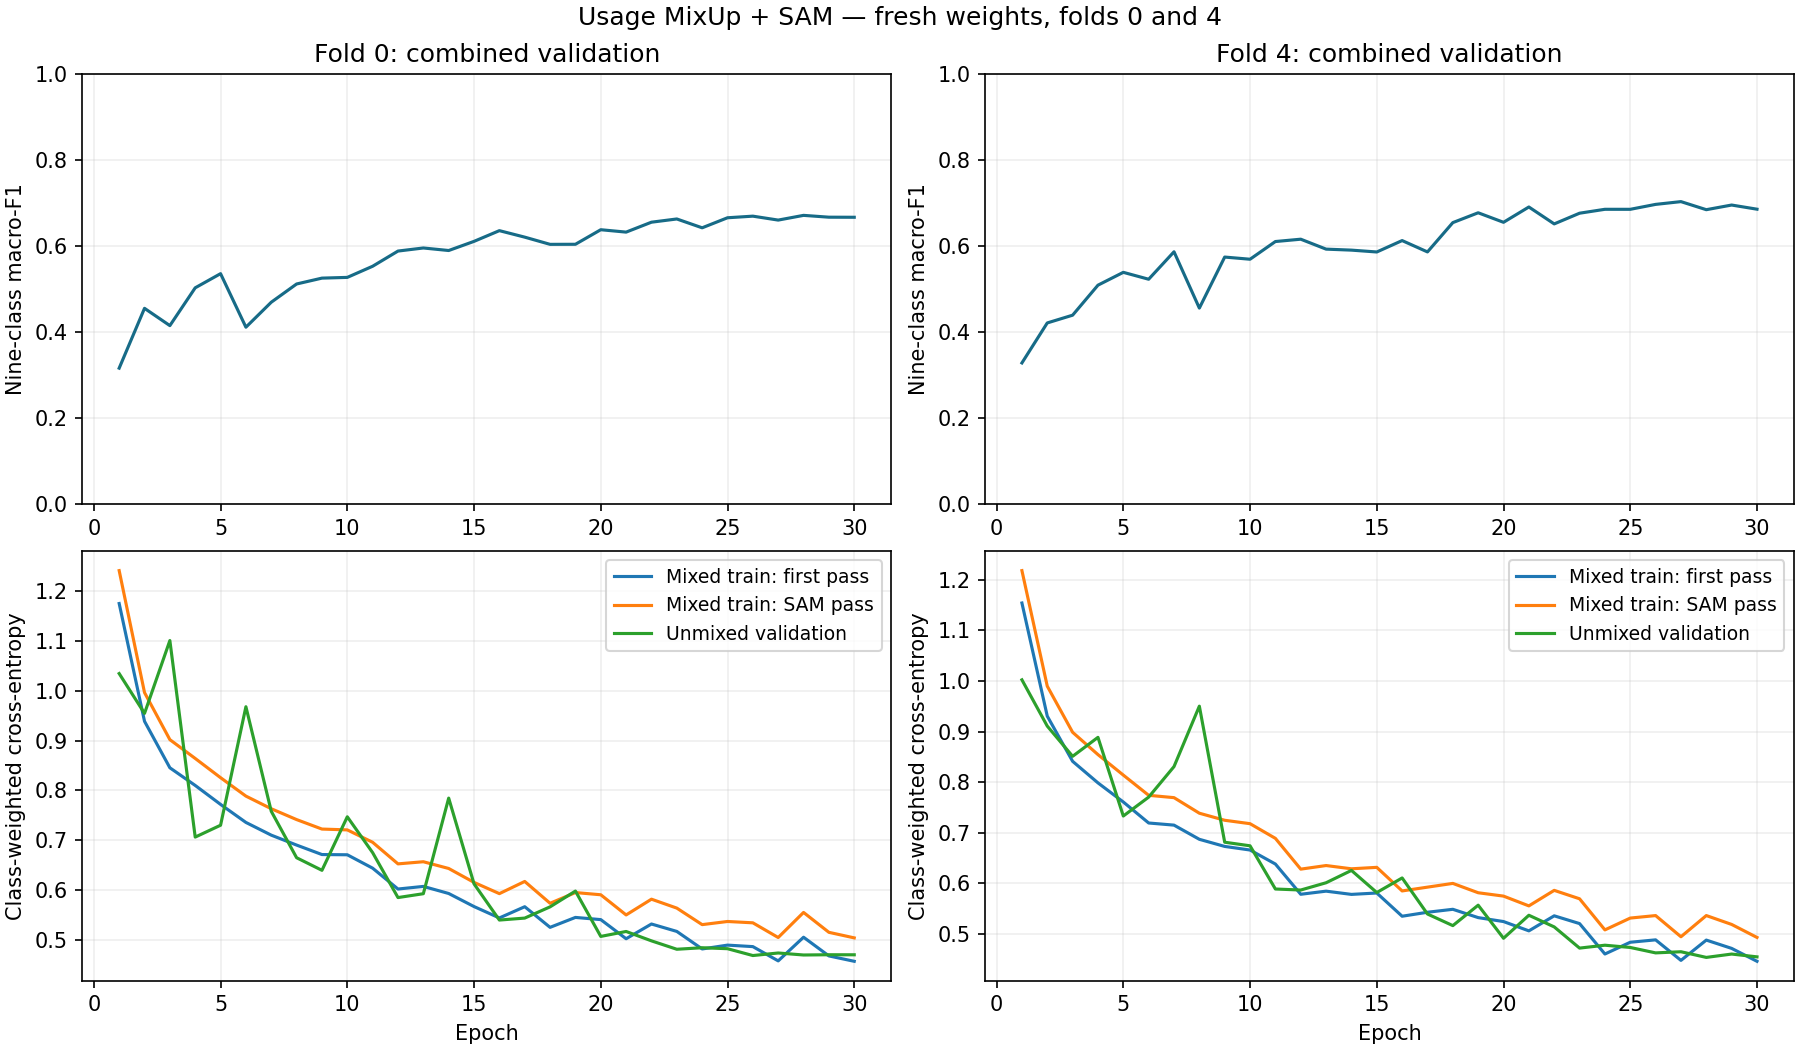

Saved curves: /content/drive/MyDrive/MLA2/task3_usage_replaced_v3_mixup_sam/results/figures/task3/usage_replaced_v3_mixup_sam_learning_curves.png


In [6]:
curve_path = save_learning_curves(
    result,
    path=DRIVE_TASK_DIR / "results/figures/task3/usage_replaced_v3_mixup_sam_learning_curves.png",
)
display(DisplayImage(filename=str(curve_path)))
print("Saved curves:", curve_path)
